In [54]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

import torch.nn as nn
import torch.optim as optim

In [55]:
print("Dataset shape:", celeba_df.shape)
print("Rows and columns in CelebA annotations")

Dataset shape: (202599, 56)
Rows and columns in CelebA annotations


In [56]:
print("First 5 image names:")
print(celeba_df["image_id"].head())

First 5 image names:
0    000001.jpg
1    000002.jpg
2    000003.jpg
3    000004.jpg
4    000005.jpg
Name: image_id, dtype: str


In [57]:
print("Partition counts:")
print(celeba_df["partition"].value_counts().sort_index())

Partition counts:
partition
0    162770
1     19867
2     19962
Name: count, dtype: int64


In [58]:
print("Top 10 attributes:")
print(celeba_df[attribute_columns].sum().sort_values(ascending=False).head(10))

Top 10 attributes:
No_Beard               169158
Young                  156734
Attractive             103833
Mouth_Slightly_Open     97942
Smiling                 97669
Wearing_Lipstick        95715
High_Cheekbones         92189
Male                    84434
Heavy_Makeup            78390
Wavy_Hair               64744
dtype: int64


In [59]:
sample_row = celeba_df.iloc[0]
print(sample_row["image_id"])
print(sample_row[attribute_columns].head())

000001.jpg
5_o_Clock_Shadow    0
Arched_Eyebrows     1
Attractive          1
Bags_Under_Eyes     0
Bald                0
Name: 0, dtype: object


In [60]:
sample_image = Image.open(os.path.join(IMG_DIR, sample_row["image_id"])).convert("RGB")
print("Sample image loaded")

Sample image loaded


(np.float64(-0.5), np.float64(177.5), np.float64(217.5), np.float64(-0.5))

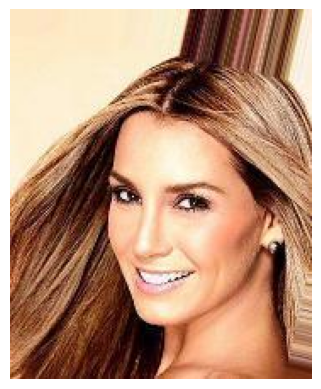

In [61]:
plt.imshow(sample_image)
plt.axis("off")

In [62]:
print("Bounding box:")
print(celeba_df.iloc[0][["x_1", "y_1", "width", "height"]].to_dict())

Bounding box:
{'x_1': 95, 'y_1': 71, 'width': 226, 'height': 313}


In [63]:
print("Landmarks:")
print(celeba_df.iloc[0][["lefteye_x", "lefteye_y", "righteye_x", "righteye_y"]].to_dict())

Landmarks:
{'lefteye_x': 69, 'lefteye_y': 109, 'righteye_x': 106, 'righteye_y': 113}


In [64]:
print("Columns in the merged dataset:")
print(celeba_df.columns[:15].tolist())

Columns in the merged dataset:
['image_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby']


In [65]:
clean_df = celeba_df.drop_duplicates().dropna().reset_index(drop=True)
print("Rows after basic clean:", len(clean_df))

Rows after basic clean: 202599


In [66]:
clean_df[attribute_columns] = clean_df[attribute_columns].replace(-1, 0).astype(np.int64)
print("Labels converted to 0/1")

Labels converted to 0/1


In [67]:
clean_df = clean_df[clean_df["image_id"].apply(lambda x: os.path.exists(os.path.join(IMG_DIR, x)))].reset_index(drop=True)
print("Rows after removing missing images:", len(clean_df))

Rows after removing missing images: 202599


In [68]:
# Cell 1: Imports, constants, and dataset paths
# ------------------------------------------------
# Purpose: load libraries, define ImageNet normalization constants,
# and set the paths to your images/CSV. Update img_dir and csv_path
# to match your dataset location on Windows.

import os
import glob
from PIL import Image
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np

# ImageNet mean/std (useful if using pretrained models)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# --- UPDATE THESE PATHS for your environment (Windows-style) ---
dataset_root = r'd:\FacialAnalysis_DL\Dataset'
# Auto-discover the image directory under Dataset (pick dir with most images)
import glob
candidates = []
for root, dirs, files in os.walk(dataset_root):
    for d in dirs:
        p = os.path.join(root, d)
        cnt = 0
        for ext in ('.jpg', '.jpeg', '.png'):
            cnt += len(glob.glob(os.path.join(p, f'*{ext}')))
        if cnt > 0:
            candidates.append((p, cnt))
if candidates:
    candidates.sort(key=lambda x: -x[1])
    img_dir = candidates[0][0]
    print('Auto-selected img_dir =', img_dir, 'with', candidates[0][1], 'images')
else:
    # fallback: try common paths
    trial = os.path.join(dataset_root, 'img_align_celeba', 'img_align_celeba')
    if os.path.exists(trial):
        img_dir = trial
        print('Falling back to', trial)
    else:
        raise RuntimeError(f'No image directories found under {dataset_root}')

# CSV path: use list_attr_celeba.csv if it exists under Dataset
csv_candidate = os.path.join(dataset_root, 'list_attr_celeba.csv')
csv_path = csv_candidate if os.path.exists(csv_candidate) else None
print('Using csv_path =', csv_path)


# Example assumes images are in Dataset\img_align and attributes CSV is list_attr_celeba.csv
img_dir  = r'd:\FacialAnalysis_DL\Dataset\img_align_celeba\img_align_celeba'          # folder with image files
csv_path = r'd:\FacialAnalysis_DL\Dataset\list_attr_celeba.csv'   # optional attributes CSV (or set to None)

# Notes:
# - If you don't have a CSV or don't want labels, set csv_path = None
# - On Windows, prefer num_workers=0 when creating DataLoader to avoid worker-launch issues


Auto-selected img_dir = d:\FacialAnalysis_DL\Dataset\img_align_celeba\img_align_celeba with 202599 images
Using csv_path = d:\FacialAnalysis_DL\Dataset\list_attr_celeba.csv


In [69]:
# Cell 2: Compact Dataset class that loads images and optional labels
# ------------------------------------------------
# Purpose: read image file list, optionally map filenames -> labels using a CSV,
# and return (image_tensor, label) or (image_tensor, filename) if no labels present.

class NotebookImageDataset(Dataset):
    def __init__(self, img_dir, csv_path=None, filename_col='image_id', label_cols=None, transform=None, exts=('.jpg', '.png', '.jpeg')):
        """
        img_dir: folder with images
        csv_path: optional csv mapping filenames to attributes
        filename_col: name of the filename column in CSV (defaults to first column if not found)
        label_cols: list of columns to use as labels (None => use all columns)
        transform: torchvision transform to apply to PIL image
        """
        self.transform = transform

        # Gather image files (supports multiple extensions)
        files = []
        for ext in exts:
            files += glob.glob(os.path.join(img_dir, f'*{ext}'))
        self.files = sorted(files)

        # Load labels if CSV provided
        self.labels = None
        self.label_cols = []
        if csv_path is not None and os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            # choose filename column (fallback to first column)
            if filename_col not in df.columns:
                filename_col = df.columns[0]
            df = df.set_index(filename_col)
            if label_cols is None:
                label_cols = [c for c in df.columns]
            self.label_cols = label_cols

            # Build mapping filename -> tensor(labels)
            self.labels = {}
            for fname, row in df[label_cols].iterrows():
                vals = row.tolist() if hasattr(row, 'tolist') else [row]
                # convert to ints if needed, and convert CelebA -1/1 to 0/1
                vals = [int(v) for v in vals]
                vals = [(1 if v == 1 else 0) if v in (-1, 1) else v for v in vals]
                # store label tensor; ensure filename string matches actual file basename
                self.labels[str(fname)] = torch.tensor(vals, dtype=torch.float32)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        # load image
        path = self.files[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        name = os.path.basename(path)
        if self.labels is not None:
            label = self.labels.get(name)
            if label is None:
                # if CSV didn't contain this image, return zeros for label shape
                label = torch.zeros(len(self.label_cols), dtype=torch.float32)
            return img, label
        else:
            return img, name


In [70]:
# Debug / create dataloaders
# This cell prints img_dir info and lists sample files before creating the loaders
import os, glob
print('Resolved img_dir =', img_dir)
print('Exists:', os.path.exists(img_dir))
# look for typical image extensions
files = []
for ext in ('.jpg', '.jpeg', '.png'):
    files.extend(glob.glob(os.path.join(img_dir, f'*{ext}')))
files = sorted(files)
print('Number of image files found in img_dir:', len(files))
if len(files) > 0:
    print('First 10 filenames:', [os.path.basename(p) for p in files[:10]])
else:
    # print parent folder contents for diagnosis
    parent = os.path.dirname(img_dir)
    print('Parent folder:', parent)
    try:
        parent_list = sorted(os.listdir(parent))
        print('Sample entries in parent (first 20):', parent_list[:20])
    except Exception as e:
        print('Could not list parent folder:', e)
    # also try deeper nested folder detection
    nested = []
    for entry in parent_list[:50] if 'parent_list' in locals() else []:
        p = os.path.join(parent, entry)
        if os.path.isdir(p):
            nested_files = []
            for ext in ('.jpg', '.jpeg', '.png'):
                nested_files.extend(glob.glob(os.path.join(p, f'*{ext}')))
            if nested_files:
                nested.append((p, len(nested_files)))
    print('Nested dirs with image counts (if any):', nested[:10])
    raise RuntimeError(f'No images found in {img_dir}. See parent and nested dirs printed above.')

# If we found images, create dataloaders
train_loader, val_loader = make_dataloaders(img_dir=img_dir, csv_path=csv_path,
                                            image_size=224, batch_size=16,
                                            val_fraction=0.2, num_workers=0)
print('Created train_loader and val_loader successfully')


Resolved img_dir = d:\FacialAnalysis_DL\Dataset\img_align_celeba\img_align_celeba
Exists: True
Number of image files found in img_dir: 202599
First 10 filenames: ['000001.jpg', '000002.jpg', '000003.jpg', '000004.jpg', '000005.jpg', '000006.jpg', '000007.jpg', '000008.jpg', '000009.jpg', '000010.jpg']
Created train_loader and val_loader successfully


Batch images shape: torch.Size([16, 3, 224, 224])
Labels type: <class 'torch.Tensor'>; labels info: torch.Size([16, 40])


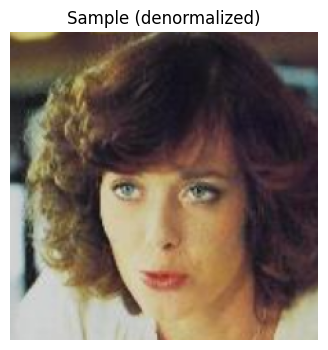

In [76]:
# Cell 4: Sanity check - examine shapes and display a denormalized sample
# ------------------------------------------------
# Purpose: verify DataLoader shapes and visualize one denormalized image
# to ensure transforms are correct.

def denormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """
    tensor: [C,H,W] or [B,C,H,W] in torch tensor format (0..1 after ToTensor then normalized)
    Returns a tensor denormalized back to 0..1 range for plotting.
    """
    t = tensor.clone()
    # support batch or single
    if t.dim() == 4:
        for c in range(3):
            t[:, c, :, :] = t[:, c, :, :] * std[c] + mean[c]
    elif t.dim() == 3:
        for c in range(3):
            t[c, :, :] = t[c, :, :] * std[c] + mean[c]
    return t

# Get one batch from training loader
batch = next(iter(train_loader))
imgs, labels_or_names = batch  # labels_or_names: tensor of labels or list of filenames
print(f"Batch images shape: {imgs.shape}")  # expected [B, 3, 224, 224]
print(f"Labels type: {type(labels_or_names)}; labels info: {getattr(labels_or_names, 'shape', labels_or_names[:4])}")

# Show first image (denormalized)
img = denormalize(imgs[0])           # [3,H,W]
img = img.permute(1, 2, 0).numpy()   # [H,W,3]
img = np.clip(img, 0, 1)
plt.figure(figsize=(4,4))
plt.imshow(img)
plt.axis('off')
plt.title('Sample (denormalized)')
plt.show()


In [80]:
# Training cell: EfficientNet-B2 two-phase training (as specified)
# ---------------------------------------------------------------
# - EfficientNet-B2 (pretrained ImageNet)
# - Replace classifier head with nn.Linear(1408, 40)
# - Loss: BCEWithLogitsLoss
# - Device: auto (cuda if available)
# PHASE 1 (epochs 1-8): freeze features, train classifier only, Adam lr=1e-3
# PHASE 2 (epochs 9-30): unfreeze all, Adam lr=1e-4, CosineAnnealingLR(T_max=22), early stopping patience=5
# Save best checkpoint to model/emotion_model.pth (based on val loss)

import os

def tqdm(iterable=None, **kwargs):
    return iterable

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import matplotlib.pyplot as plt

# ensure model output folder
os.makedirs('model', exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# Prepare dataloaders - if not present, create them with defaults
try:
    train_loader
    val_loader
    print('Found existing train_loader and val_loader')
except NameError:
    print('train_loader/val_loader not found, creating with defaults (batch_size=32)')
    train_loader, val_loader = make_dataloaders(img_dir=img_dir, csv_path=csv_path, image_size=224, batch_size=32, val_fraction=0.2, num_workers=0)

num_labels = 40

# Load EfficientNet-B2 (torchvision) pretrained
try:
    model = models.efficientnet_b2(pretrained=True)
except TypeError:
    # older torchvision API may require weights arg; try fallback
    model = models.efficientnet_b2(weights='IMAGENET1K_V1')

# Replace classifier head
in_features = None
# EfficientNet classifier is model.classifier; find in_features if possible
if hasattr(model, 'classifier'):
    if isinstance(model.classifier, nn.Sequential) and len(model.classifier) >= 2:
        try:
            in_features = model.classifier[1].in_features
        except Exception:
            in_features = None

# If in_features not found, use the requested 1408
if in_features is None:
    in_features = 1408

model.classifier = nn.Sequential(nn.Dropout(p=0.4), nn.Linear(in_features, num_labels))
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()

# Utility: validation / accuracy (multi-label accuracy using threshold 0.5)
def validate(model, loader, device):
    model.eval()
    running_loss = 0.0
    total = 0
    correct_elements = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            preds = torch.sigmoid(outputs) > 0.5
            # labels may be floats; convert to bool
            truths = labels > 0.5
            correct_elements += (preds == truths).sum().item()
            total += preds.numel()
    avg_loss = running_loss / len(loader.dataset)
    accuracy = correct_elements / total if total > 0 else 0.0
    return avg_loss, accuracy

# Utility: train one epoch
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0
    pbar = tqdm(loader, desc='training', leave=False)
    for imgs, labels in pbar:
        imgs = imgs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    avg_loss = running_loss / len(loader.dataset)
    return avg_loss

# Training schedule
phase1_epochs = 8
phase2_epochs = 22  # total epochs 30 -> phase2 from 9..30 inclusive => 22 epochs
total_epochs = phase1_epochs + phase2_epochs

best_val_loss = float('inf')
early_stop_counter = 0
patience = 5

train_losses = []
val_losses = []
val_accuracies = []

# PHASE 1: freeze features, train classifier only
for param in model.parameters():
    param.requires_grad = False
# enable classifier params
for param in model.classifier.parameters():
    param.requires_grad = True

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

print('Starting Phase 1 training (epochs 1 to', phase1_epochs, ')')
for epoch in range(1, phase1_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    print(f'Epoch {epoch:02d}/{total_epochs}  Phase1  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  val_acc={val_acc:.4f}')
    # checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'model/emotion_model.pth')
        print('Saved best model (phase1) with val_loss=', best_val_loss)
        early_stop_counter = 0
    else:
        early_stop_counter += 1
    if early_stop_counter >= patience:
        print('Early stopping triggered during phase 1')
        break

# PHASE 2: unfreeze all layers
for param in model.parameters():
    param.requires_grad = True
optimizer = optim.Adam(model.parameters(), lr=1e-4)
from torch.optim.lr_scheduler import CosineAnnealingLR
scheduler = CosineAnnealingLR(optimizer, T_max=22)

print('Starting Phase 2 training (epochs', phase1_epochs+1, 'to', total_epochs, ')')
for e in range(phase1_epochs + 1, total_epochs + 1):
    epoch_idx = e
    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    scheduler.step()
    print(f"Epoch {epoch_idx:02d}/{total_epochs}  Phase2  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  val_acc={val_acc:.4f}  lr={optimizer.param_groups[0]['lr']:.6f}")
    # checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'model/emotion_model.pth')
        print('Saved best model (phase2) with val_loss=', best_val_loss)
        early_stop_counter = 0
    else:
        early_stop_counter += 1
    if early_stop_counter >= patience:
        print('Early stopping triggered during phase 2')
        break

# After training: plot losses
plt.figure(figsize=(8,5))
plt.plot(range(1, len(train_losses)+1), train_losses, label='train_loss')
plt.plot(range(1, len(val_losses)+1), val_losses, label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.grid(True)
plt.savefig('model/training_curves.png', dpi=150)
plt.show()

print('Training complete. Best val loss:', best_val_loss)
if val_accuracies:
    print('Final val accuracy:', val_accuracies[-1])


Using device: cpu
Found existing train_loader and val_loader


c:\Users\Prakhar\ML_JOVAC\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Prakhar\ML_JOVAC\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B2_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to C:\Users\Prakhar/.cache\torch\hub\checkpoints\efficientnet_b2_rwightman-c35c1473.pth


100.0%


Starting Phase 1 training (epochs 1 to 8 )


AttributeError: 'DataLoader' object has no attribute 'set_postfix'